In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

# Self-Paced Learning

In [2]:
!pip install -q pytorch-lightning torchinfo #torch torchvision matplotlib

In [3]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torchinfo import summary
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

pl.seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INFO:lightning_fabric.utilities.seed:Seed set to 42


## Dataset

In [4]:
## Dataset / DataModule (+ 난이도 점수 주입)
class IndexedFashionMNIST(datasets.FashionMNIST):
    """ __getitem__에서 (img, target, idx, difficulty) 반환 """
    def __init__(self, *args, difficulties=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.difficulties = difficulties  # None 가능
    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        diff = -1.0 if self.difficulties is None else float(self.difficulties[index])
        return img, target, index, diff

class FMNISTDataModule(pl.LightningDataModule):
    def __init__(self, batch_size=128, num_workers=4, diff_mode="hybrid"):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.diff_mode = diff_mode
        self.train_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        self.test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        self.train_difficulties = None

    def prepare_data(self):
        datasets.FashionMNIST(root="./data", train=True,  download=True)
        datasets.FashionMNIST(root="./data", train=False, download=True)

    def setup(self, stage=None):
        self.train_set = IndexedFashionMNIST(
            root="./data", train=True, download=True, transform=self.train_transform,
            difficulties=self.train_difficulties
        )
        self.val_set = IndexedFashionMNIST(
            root="./data", train=False, download=True, transform=self.test_transform,
            difficulties=None
        )

    def set_train_difficulties(self, diffs):
        """난이도 점수를 외부에서 계산하여 주입"""
        self.train_difficulties = diffs

    def train_dataloader(self):
        return DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True,
                          num_workers=self.num_workers, pin_memory=True)
    def val_dataloader(self):
        return DataLoader(self.val_set, batch_size=self.batch_size*2, shuffle=False,
                          num_workers=self.num_workers, pin_memory=True)

In [5]:
### CNN Model
class BaseCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28->14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14->7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.feature(x)
        x = self.classifier(x)
        return x

summary(BaseCNN(), (64, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
BaseCNN                                  [64, 10]                  --
├─Sequential: 1-1                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          320
│    └─ReLU: 2-2                         [64, 32, 28, 28]          --
│    └─Conv2d: 2-3                       [64, 32, 28, 28]          9,248
│    └─ReLU: 2-4                         [64, 32, 28, 28]          --
│    └─MaxPool2d: 2-5                    [64, 32, 14, 14]          --
│    └─Conv2d: 2-6                       [64, 64, 14, 14]          18,496
│    └─ReLU: 2-7                         [64, 64, 14, 14]          --
│    └─Conv2d: 2-8                       [64, 64, 14, 14]          36,928
│    └─ReLU: 2-9                         [64, 64, 14, 14]          --
│    └─MaxPool2d: 2-10                   [64, 64, 7, 7]            --
├─Sequential: 1-2                        [64, 10]                  --
│  

In [6]:
### Estimator Model
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28->14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14->7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 64), nn.ReLU(inplace=True),
#            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.feature(x)
        x = self.classifier(x)
        return x

summary(SmallCNN(), (64, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SmallCNN                                 [64, 10]                  --
├─Sequential: 1-1                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          320
│    └─ReLU: 2-2                         [64, 32, 28, 28]          --
│    └─MaxPool2d: 2-3                    [64, 32, 14, 14]          --
│    └─Conv2d: 2-4                       [64, 64, 14, 14]          18,496
│    └─ReLU: 2-5                         [64, 64, 14, 14]          --
│    └─MaxPool2d: 2-6                    [64, 64, 7, 7]            --
├─Sequential: 1-2                        [64, 10]                  --
│    └─Flatten: 2-7                      [64, 3136]                --
│    └─Linear: 2-8                       [64, 64]                  200,768
│    └─ReLU: 2-9                         [64, 64]                  --
│    └─Linear: 2-10                      [64, 10]                  650
Tota

In [7]:
### 난이도 측정기
#  - warmup_ce: 얕은 모델을 1~2 epoch 학습 후 per-sample CE 측정
#  - entropy  : 입력 이미지의 엔트로피(정보량) 기반
#  - hybrid   : 위 두 신호를 정규화 후 가중합
class DifficultyEstimator:
    def __init__(self, mode="hybrid", warmup_epochs=1, alpha=0.7):
        """
        mode: 'warmup_ce' | 'entropy' | 'hybrid'
        warmup_epochs: warmup 학습 epoch 수
        alpha: hybrid 결합 가중치 (diff = alpha*CE + (1-alpha)*Entropy)
        """
        self.mode = mode
        self.warmup_epochs = warmup_epochs
        self.alpha = alpha

    @torch.no_grad()
    def _image_entropy(self, loader):
        """ 이미지를 [0,1]로 보고, 256-bin histogram 기반 엔트로피 근사 """
        ent = np.zeros(len(loader.dataset), dtype=np.float32)
        for x, y, idx, _ in loader:
            # x: (B,1,28,28), 0~1 정규화 가정 (ToTensor)
            x = x.clamp(0, 1)  # 안전
            # 히스토그램 기반 엔트로피
            x_np = (x.squeeze(1).cpu().numpy() * 255).astype(np.uint8)  # (B,28,28)
            for i, im in enumerate(x_np):
                hist, _ = np.histogram(im, bins=256, range=(0,255), density=True)
                p = hist + 1e-12
                ent[idx[i]] = float(-(p*np.log(p)).sum())
        return ent

    def _warmup_ce(self, model, train_loader, val_loader, lr=2e-3):
        model = model.to(device)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
        # 아주 짧게 warmup 학습
        model.train()
        for ep in range(self.warmup_epochs):
            for x, y, _, _ in train_loader:
                x, y = x.to(device), y.to(device)
                opt.zero_grad(set_to_none=True)
                logits = model(x)
                loss = F.cross_entropy(logits, y)
                loss.backward()
                opt.step()
        # per-sample CE 추출 (train 전체 한 번 pass)
        ce = np.zeros(len(train_loader.dataset), dtype=np.float32)
        model.eval()
        with torch.no_grad():
            for x, y, idx, _ in train_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                ce_each = F.cross_entropy(logits, y, reduction='none')  # (B,)
                pred = logits.argmax(dim=1)
                acc = (pred == y).float().mean()
                for i, id_ in enumerate(idx):
                    ce[id_.item()] = float(ce_each[i].detach().cpu())
                print(f"acc:{acc:.3f}")
        return ce

    def fit_transform(self, datamodule: FMNISTDataModule):
        """ datamodule로부터 난이도 점수 벡터 반환 (train set 길이) """
        dm = datamodule
        dm.setup("fit")
        train_loader = DataLoader(dm.train_set, batch_size=256, shuffle=False,
                                  num_workers=dm.num_workers, pin_memory=True)
        val_loader   = DataLoader(dm.val_set,   batch_size=256, shuffle=False,
                                  num_workers=dm.num_workers, pin_memory=True)

        diffs = None
        if self.mode in ["warmup_ce", "hybrid"]:
            base = SmallCNN()
            ce = self._warmup_ce(base, train_loader, val_loader)
            # 0-1 정규화
            ce = (ce - ce.min()) / (ce.max() - ce.min() + 1e-12)

        if self.mode in ["entropy", "hybrid"]:
            ent = self._image_entropy(train_loader)
            ent = (ent - ent.min()) / (ent.max() - ent.min() + 1e-12)

        if self.mode == "warmup_ce":
            diffs = ce
        elif self.mode == "entropy":
            diffs = ent
        else:  # hybrid
            diffs = self.alpha * ce + (1 - self.alpha) * ent

        # 다시 0-1 normalize (결과 안정화)
        diffs = (diffs - diffs.min()) / (diffs.max() - diffs.min() + 1e-12)
        return diffs.astype(np.float32)


In [10]:
### Self-Paced LightningModule
# - mode: 'soft' (연속 가중), 'hard' (이진 선택)
# - λ 스케줄: lambda_t = lambda_start * (1 + grow_rate * epoch)
# - 로그: train_ce, train_keep, lambda, val_acc, val_loss
class LitSPL(pl.LightningModule):
    def __init__(self,
                 lr=2e-3,
                 weight_decay=1e-4,
                 lambda_start=0.8,
                 grow_rate=0.25,
                 mode="soft",
                 min_keep_ratio=0.05):
        super().__init__()
        self.save_hyperparameters()

        self.model = BaseCNN()
        self.lr = lr
        self.weight_decay = weight_decay
        self.lambda_start = lambda_start
        self.grow_rate = grow_rate
        self.mode = mode
        self.min_keep_ratio = min_keep_ratio

        # 로그(곡선 시각화를 위해 저장)
        self.history = {
            "epoch": [],
            "lambda": [],
            "train_keep": [],
            "val_acc": [],
            "val_loss": [],
            "train_ce": [],
            "train_spl": [],
        }

    def _lambda_at(self, epoch_idx):
        return self.lambda_start * (1.0 + self.grow_rate * epoch_idx)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)

    def training_step(self, batch, batch_idx):
        x, y, idx, diff = batch
        logits = self.model(x)
        ce_each = F.cross_entropy(logits, y, reduction='none')  # (B,)
        pred = logits.argmax(dim=1)
        acc = (pred == y).float().mean()

        # 현재 epoch의 λ
        lam = self._lambda_at(self.current_epoch)

        # Self-Paced weight
        if self.mode == "hard":
            w = (ce_each.detach() <= lam).float()
        else:
            w = (1.0 - ce_each.detach() / lam).clamp(min=0.0, max=1.0)

        # 최소 유지 비율
        if w.sum() < self.min_keep_ratio * w.numel():
            k = max(1, int(self.min_keep_ratio * w.numel()))
            topk_idx = torch.topk(-ce_each, k=k).indices  # 작은 CE 상위 k (=-loss)
            w[topk_idx] = 1.0

        # 가중 손실
        weighted_loss = (w * ce_each).sum() / (w.sum() + 1e-8)
        ce_mean = ce_each.mean()

        # 로그 (epoch 단위)
        self.log_dict(
            {"train_acc":acc, "train_spl": weighted_loss, "train_ce": ce_mean, "train_keep": w.mean()},
            on_step=False, on_epoch=True, prog_bar=True
        )
        return weighted_loss

    def validation_step(self, batch, batch_idx):
        x, y, idx, diff = batch
        logits = self.model(x)
        loss = F.cross_entropy(logits, y)
        pred = logits.argmax(dim=1)
        acc = (pred == y).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc}, on_step=False, on_epoch=True, prog_bar=True)
        return {"val_loss": loss.detach(), "val_acc": acc.detach()}

    def on_validation_epoch_end(self):
        # 로그 값 수집(시각화용)
        metrics = self.trainer.callback_metrics
        keep_ratio = metrics.get("train_keep_epoch") or metrics.get("train_keep")
        train_ce = metrics.get("train_ce_epoch") or metrics.get("train_ce")
        train_spl = metrics.get("train_spl_epoch") or metrics.get("train_spl")
        val_acc = metrics.get("val_acc")
        val_loss = metrics.get("val_loss")
        lam = self._lambda_at(self.current_epoch)

        self.history["epoch"].append(int(self.current_epoch))
        self.history["lambda"].append(float(lam))
        self.history["train_keep"].append(float(keep_ratio.cpu()) if keep_ratio is not None else np.nan)
        self.history["train_ce"].append(float(train_ce.cpu()) if train_ce is not None else np.nan)
        self.history["train_spl"].append(float(train_spl.cpu()) if train_spl is not None else np.nan)
        self.history["val_acc"].append(float(val_acc.cpu()) if val_acc is not None else np.nan)
        self.history["val_loss"].append(float(val_loss.cpu()) if val_loss is not None else np.nan)


## 난이도 측정, 주입

In [11]:
# DataModule 생성
dm = FMNISTDataModule(batch_size=128, num_workers=4)

# 난이도 측정
#  - mode='warmup_ce' | 'entropy' | 'hybrid'
estimator = DifficultyEstimator(mode="hybrid", warmup_epochs=1, alpha=0.7)
diffs = estimator.fit_transform(dm)     # np.ndarray [N_train], 0~1

# 난이도 주입
dm.set_train_difficulties(diffs)
dm.setup("fit")

acc:0.902
acc:0.863
acc:0.867
acc:0.879
acc:0.836
acc:0.875
acc:0.875
acc:0.824
acc:0.855
acc:0.871
acc:0.848
acc:0.871
acc:0.867
acc:0.848
acc:0.871
acc:0.801
acc:0.883
acc:0.926
acc:0.898
acc:0.836
acc:0.852
acc:0.844
acc:0.867
acc:0.840
acc:0.848
acc:0.871
acc:0.871
acc:0.848
acc:0.840
acc:0.820
acc:0.875
acc:0.879
acc:0.867
acc:0.852
acc:0.844
acc:0.887
acc:0.855
acc:0.879
acc:0.859
acc:0.895
acc:0.875
acc:0.898
acc:0.875
acc:0.855
acc:0.887
acc:0.840
acc:0.848
acc:0.863
acc:0.848
acc:0.867
acc:0.910
acc:0.852
acc:0.852
acc:0.852
acc:0.871
acc:0.848
acc:0.848
acc:0.836
acc:0.883
acc:0.863
acc:0.871
acc:0.871
acc:0.863
acc:0.871
acc:0.852
acc:0.859
acc:0.867
acc:0.820
acc:0.852
acc:0.855
acc:0.840
acc:0.883
acc:0.887
acc:0.855
acc:0.855
acc:0.840
acc:0.887
acc:0.820
acc:0.867
acc:0.852
acc:0.879
acc:0.867
acc:0.883
acc:0.840
acc:0.895
acc:0.887
acc:0.879
acc:0.910
acc:0.863
acc:0.863
acc:0.887
acc:0.887
acc:0.848
acc:0.875
acc:0.891
acc:0.859
acc:0.875
acc:0.910
acc:0.883
acc:0.840


## 학습

In [12]:
# SPL LightningModule
model = LitSPL(
    lr=2e-3,
    weight_decay=1e-4,
    lambda_start=0.8,   # 초기 허용 난이도(CE 기준)
    grow_rate=0.25,     # epoch별 증가율
    mode="soft",        # 'soft' 또는 'hard'
    min_keep_ratio=0.05 # 최소 유지 비율
)

# 학습
trainer = pl.Trainer(
    max_epochs=10,
#    deterministic=True,
    enable_progress_bar=True,
    log_every_n_steps=10,
)
trainer.fit(model, datamodule=dm)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callback

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


## 결과 시각화

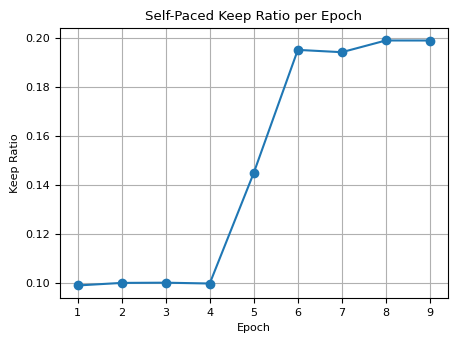

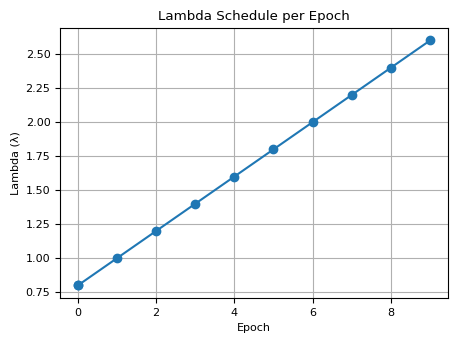

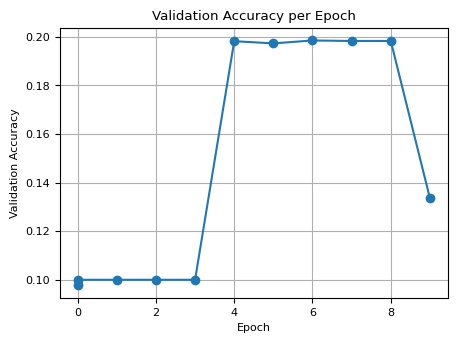

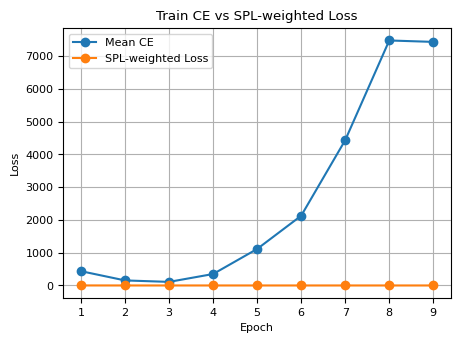

In [41]:
# 시각화: keep 비율 / λ / val acc (각각 단일 플롯)
hist = model.history
epochs = hist["epoch"]

# keep ratio
plt.plot(epochs, hist["train_keep"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Keep Ratio")
plt.title("Self-Paced Keep Ratio per Epoch")
plt.grid(True)
plt.show()

# lambda
plt.plot(epochs, hist["lambda"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Lambda (λ)")
plt.title("Lambda Schedule per Epoch")
plt.grid(True)
plt.show()

# Validation Accuracy
plt.plot(epochs, hist["val_acc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.grid(True)
plt.show()

# train_ce vs train_spl 비교
plt.plot(epochs, hist["train_ce"], marker="o", label="Mean CE")
plt.plot(epochs, hist["train_spl"], marker="o", label="SPL-weighted Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train CE vs SPL-weighted Loss")
plt.grid(True)
plt.legend()
plt.show()
